# Adaptive Self-Rehearsal for Instruction-Tuned LLMs

Qwen2.5-3B, full SFT. Self-Instruct 2K (3 seeds) + Alpaca 52K (2 seeds).  
13 top-level benchmarks + 57 MMLU subjects via lm-eval.


In [1]:
%matplotlib inline
import json, os, glob, statistics, math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BASE_DIR = 'final_backup/results'


/home/vivaswan/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def load_all(root):
    merged = {}
    for dirpath, _, files in os.walk(root):
        for f in sorted(files):
            if f.startswith('results_') and f.endswith('.json'):
                data = json.load(open(os.path.join(dirpath, f)))
                for task, metrics in data['results'].items():
                    if task not in merged:
                        merged[task] = metrics
    return merged

SCORE_KEYS = ['acc_norm,none', 'acc,none',
              'exact_match,strict-match', 'exact_match,remove_whitespace',
              'exact_match,none']

def score(m):
    for k in SCORE_KEYS:
        if k in m and m[k] is not None:
            return m[k] * 100
    return None

def stats(task, seeds):
    b = score(conds['base'].get(task, {}))
    vals = [score(conds[s].get(task, {})) for s in seeds]
    vals = [v for v in vals if v is not None]
    if not vals:
        return None, 0, None, b
    m = statistics.mean(vals)
    se = statistics.stdev(vals) / math.sqrt(len(vals)) if len(vals) > 1 else 0
    delta = (m - b) if b else None
    return m, se, delta, b


In [3]:
conds = {
    'base':     load_all(os.path.join(BASE_DIR, 'base')),
    '2k_s42':   load_all(os.path.join(BASE_DIR, 'instruct', 'seed42-ep4')),
    '2k_s1337': load_all(os.path.join(BASE_DIR, 'instruct', 'seed1337-ep4')),
    '2k_s2025': load_all(os.path.join(BASE_DIR, 'instruct', 'seed2025-ep4')),
    '52k_s42':  load_all(os.path.join(BASE_DIR, 'alpaca52k', 'seed42-ep1')),
    '52k_s1337':load_all(os.path.join(BASE_DIR, 'alpaca52k', 'seed1337-ep1')),
}

SEEDS_2K  = ['2k_s42', '2k_s1337', '2k_s2025']
SEEDS_52K = ['52k_s42', '52k_s1337']

TOP_TASKS = ['arc_challenge','arc_easy','boolq','rte','copa',
             'gsm8k','lambada_openai','piqa','hellaswag',
             'winogrande','openbookqa','triviaqa','mmlu']

LABELS = {
    'arc_challenge':'ARC-Chal','arc_easy':'ARC-Easy','boolq':'BoolQ',
    'rte':'RTE','copa':'COPA','gsm8k':'GSM8K','lambada_openai':'LAMBADA',
    'piqa':'PIQA','hellaswag':'HellaSwag','winogrande':'WinoGrande',
    'openbookqa':'OBQA','triviaqa':'TriviaQA','mmlu':'MMLU',
}

print(f"base: {len(conds['base'])} tasks")
print(f"2K seeds: {len(SEEDS_2K)}, 52K seeds: {len(SEEDS_52K)}")


base: 74 tasks
2K seeds: 3, 52K seeds: 2


In [4]:
print(f"{'Task':<14} {'Base':>7} {'2K':>8} {'d2K':>7} {'52K':>8} {'d52K':>7}")
print("-"*55)
for t in TOP_TASKS:
    b = score(conds['base'].get(t, {}))
    m2, se2, d2, _ = stats(t, SEEDS_2K)
    m5, se5, d5, _ = stats(t, SEEDS_52K)
    if b and m2 and m5:
        print(f"{LABELS[t]:<14} {b:>7.2f} {m2:>8.2f} {d2:>+7.2f} {m5:>8.2f} {d5:>+7.2f}")


Task              Base       2K     d2K      52K    d52K
-------------------------------------------------------
ARC-Chal         47.27    49.83   +2.56    51.15   +3.88
ARC-Easy         73.11    78.44   +5.33    77.95   +4.84
BoolQ            77.25    80.05   +2.80    82.75   +5.50
RTE              75.45    83.27   +7.82    70.40   -5.05
COPA             85.00    80.00   -5.00    88.00   +3.00
GSM8K            71.04    67.68   -3.36    55.69  -15.35
LAMBADA          67.15    64.75   -2.40    62.90   -4.25
PIQA             78.89    77.22   -1.67    78.40   -0.49
HellaSwag        73.54    72.75   -0.79    72.48   -1.06
WinoGrande       68.43    69.35   +0.92    69.85   +1.42
OBQA             42.00    42.87   +0.87    43.10   +1.10
TriviaQA         39.90    40.32   +0.42    23.10  -16.80
MMLU             65.18    64.26   -0.92    62.95   -2.23


In [5]:
GROUP = ['mmlu_stem','mmlu_other','mmlu_social_sciences','mmlu_humanities','mmlu']
mmlu_subj = [t for t in conds['base'] if t.startswith('mmlu_') and t not in GROUP]

def fgt(task, seeds):
    b = score(conds['base'].get(task, {}))
    if not b: return None, None
    vals = [(b - score(conds[s].get(task,{}))) / b * 100
            for s in seeds if score(conds[s].get(task,{})) is not None]
    if not vals: return None, None
    m = statistics.mean(vals)
    se = statistics.stdev(vals)/math.sqrt(len(vals)) if len(vals) > 1 else 0
    return m, se

fgt_2k = {t: fgt(t, SEEDS_2K) for t in mmlu_subj}
fgt_2k = {t:v for t,v in fgt_2k.items() if v[0] is not None}
sorted_2k = sorted(fgt_2k.items(), key=lambda x: x[1][0], reverse=True)

spread = sorted_2k[0][1][0] - sorted_2k[-1][1][0]
print(f"{len(sorted_2k)} subjects, spread: {spread:.1f}pp")
print()
print("most forgotten:")
for t,(m,se) in sorted_2k[:5]:
    print(f"  {t.replace('mmlu_','').replace('_',' ').title():<35} {m:+.2f} +/-{se:.2f}")
print()
print("most improved:")
for t,(m,se) in sorted_2k[-5:]:
    print(f"  {t.replace('mmlu_','').replace('_',' ').title():<35} {m:+.2f} +/-{se:.2f}")


57 subjects, spread: 26.1pp

most forgotten:
  Abstract Algebra                    +19.87 +/-1.28
  College Physics                     +17.65 +/-2.26
  Formal Logic                        +13.98 +/-1.42
  College Chemistry                   +8.00 +/-1.15
  Electrical Engineering              +7.89 +/-0.95

most improved:
  Management                          -3.57 +/-0.69
  Human Sexuality                     -4.00 +/-0.00
  Econometrics                        -5.26 +/-1.01
  Medical Genetics                    -5.56 +/-0.00
  High School Physics                 -6.25 +/-1.56


## aggregates hide the real signal

MMLU aggregate barely moves after SFT (-0.92pp).  
But subjects diverge by ~26pp underneath. Some collapse, some improve.


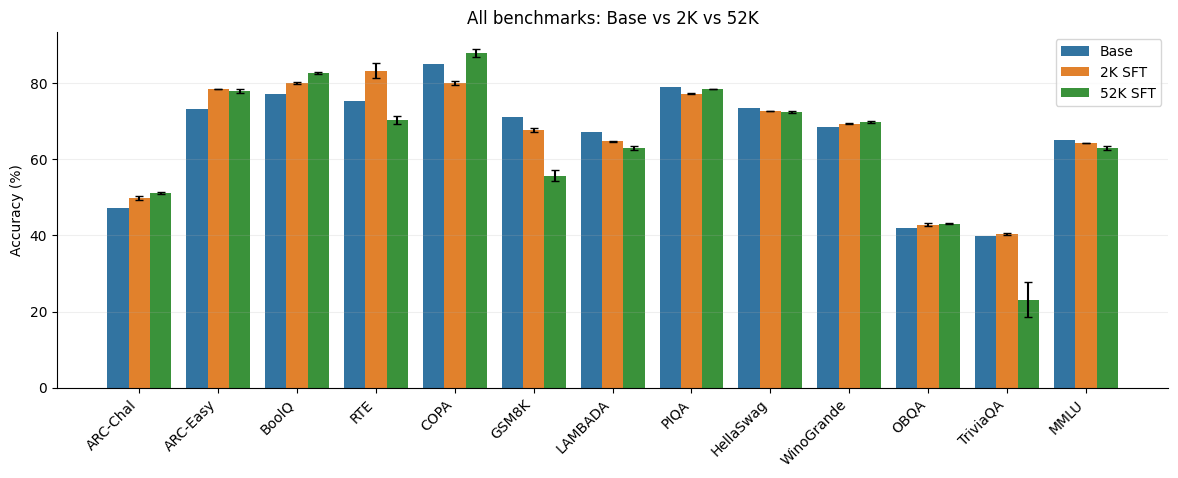

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(TOP_TASKS))
w = 0.27

base_v = [score(conds['base'].get(t,{})) for t in TOP_TASKS]
m2k, se2k, m52k, se52k = [], [], [], []
for t in TOP_TASKS:
    m, se, _, _ = stats(t, SEEDS_2K);  m2k.append(m);  se2k.append(se)
    m, se, _, _ = stats(t, SEEDS_52K); m52k.append(m); se52k.append(se)

ax.bar(x - w, base_v, w, label='Base', color='#3274A1')
ax.bar(x,     m2k,   w, label='2K SFT', color='#E1812C', yerr=se2k, capsize=3)
ax.bar(x + w, m52k,  w, label='52K SFT', color='#3A923A', yerr=se52k, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[t] for t in TOP_TASKS], rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('All benchmarks: Base vs 2K vs 52K')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(pad=1.5)
plt.show()


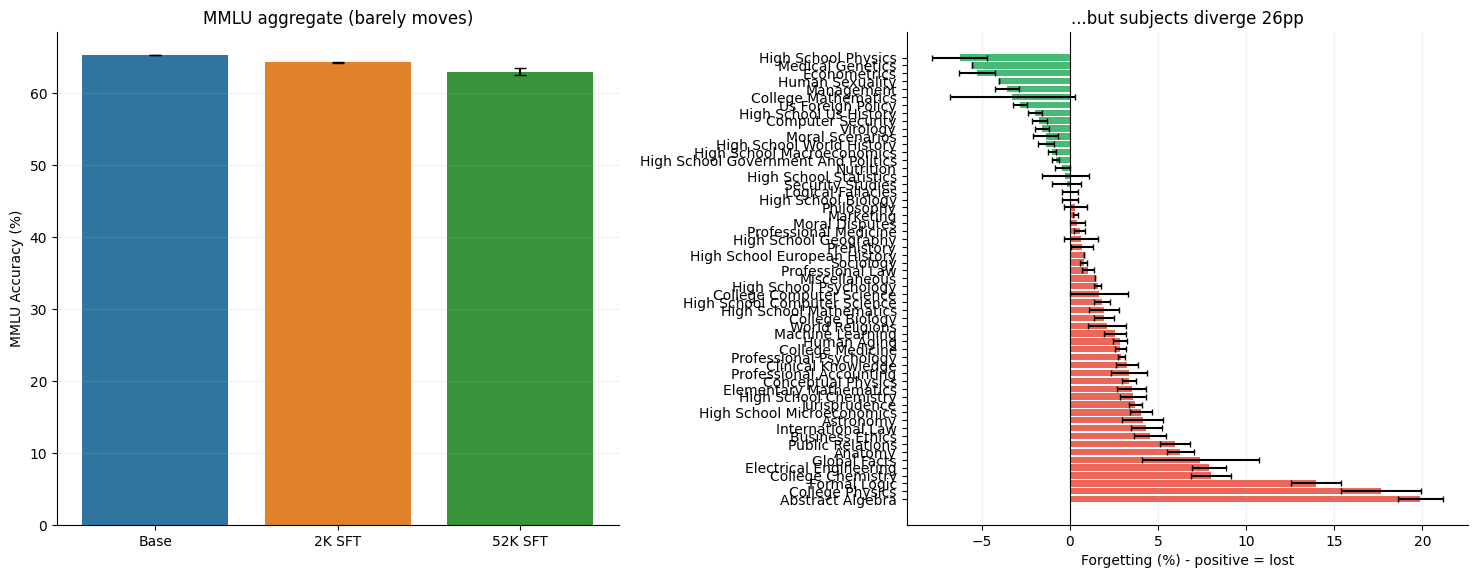

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# left: MMLU aggregate
m2, se2, _, b = stats('mmlu', SEEDS_2K)
m5, se5, _, _ = stats('mmlu', SEEDS_52K)
ax1.bar(['Base','2K SFT','52K SFT'], [b, m2, m5],
        color=['#3274A1','#E1812C','#3A923A'],
        yerr=[0, se2, se5], capsize=4)
ax1.set_ylabel('MMLU Accuracy (%)')
ax1.set_title('MMLU aggregate (barely moves)')
ax1.grid(axis='y', alpha=0.2)

# right: subject spread
labels = [t.replace('mmlu_','').replace('_',' ').title() for t,_ in sorted_2k]
vals = [v[0] for _,v in sorted_2k]
errs = [v[1] for _,v in sorted_2k]
colors = ['#E74C3C' if v > 0 else '#27AE60' for v in vals]

ax2.barh(labels, vals, xerr=errs, color=colors, alpha=0.85, capsize=2)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('Forgetting (%) - positive = lost')
ax2.set_title(f'...but subjects diverge {spread:.0f}pp')
ax2.grid(axis='x', alpha=0.2)

plt.tight_layout(pad=1.5)
plt.show()


## not subject taxonomy - cognitive axis

The pattern doesn't follow subject lines:

- HS Physics +6.3% vs College Physics -17.6% (both physics)
- ARC-Easy +5.3% vs COPA -5.9% (both reasoning)

What separates them: multi-step derivation degrades, pattern recognition/recall improves.


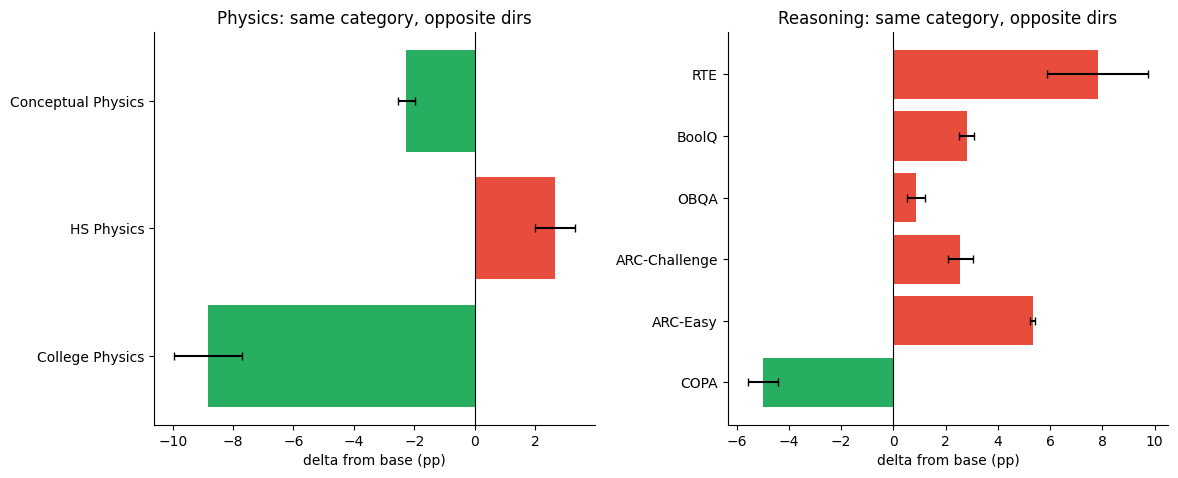

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def subj_delta(task, seeds=SEEDS_2K):
    b = score(conds['base'].get(task, {}))
    vals = [score(conds[s].get(task,{})) for s in seeds]
    vals = [v for v in vals if v is not None]
    if not vals or not b: return None, 0
    m = statistics.mean(vals)
    se = statistics.stdev(vals)/math.sqrt(len(vals)) if len(vals)>1 else 0
    return m - b, se

# physics
phys = [('mmlu_college_physics','College Physics'),
        ('mmlu_high_school_physics','HS Physics'),
        ('mmlu_conceptual_physics','Conceptual Physics')]
deltas = [subj_delta(t) for t,_ in phys]
ax1.barh([l for _,l in phys], [d[0] for d in deltas], xerr=[d[1] for d in deltas],
         color=['#E74C3C' if d[0]>0 else '#27AE60' for d in deltas], capsize=3)
ax1.axvline(0, color='black', lw=0.8)
ax1.set_xlabel('delta from base (pp)')
ax1.set_title('Physics: same category, opposite dirs')

# reasoning
reas = [('copa','COPA'), ('arc_easy','ARC-Easy'), ('arc_challenge','ARC-Challenge'),
        ('openbookqa','OBQA'), ('boolq','BoolQ'), ('rte','RTE')]
deltas2 = [subj_delta(t) for t,_ in reas]
ax2.barh([l for _,l in reas], [d[0] for d in deltas2], xerr=[d[1] for d in deltas2],
         color=['#E74C3C' if d[0]>0 else '#27AE60' for d in deltas2], capsize=3)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('delta from base (pp)')
ax2.set_title('Reasoning: same category, opposite dirs')

plt.tight_layout(pad=1.5)
plt.show()


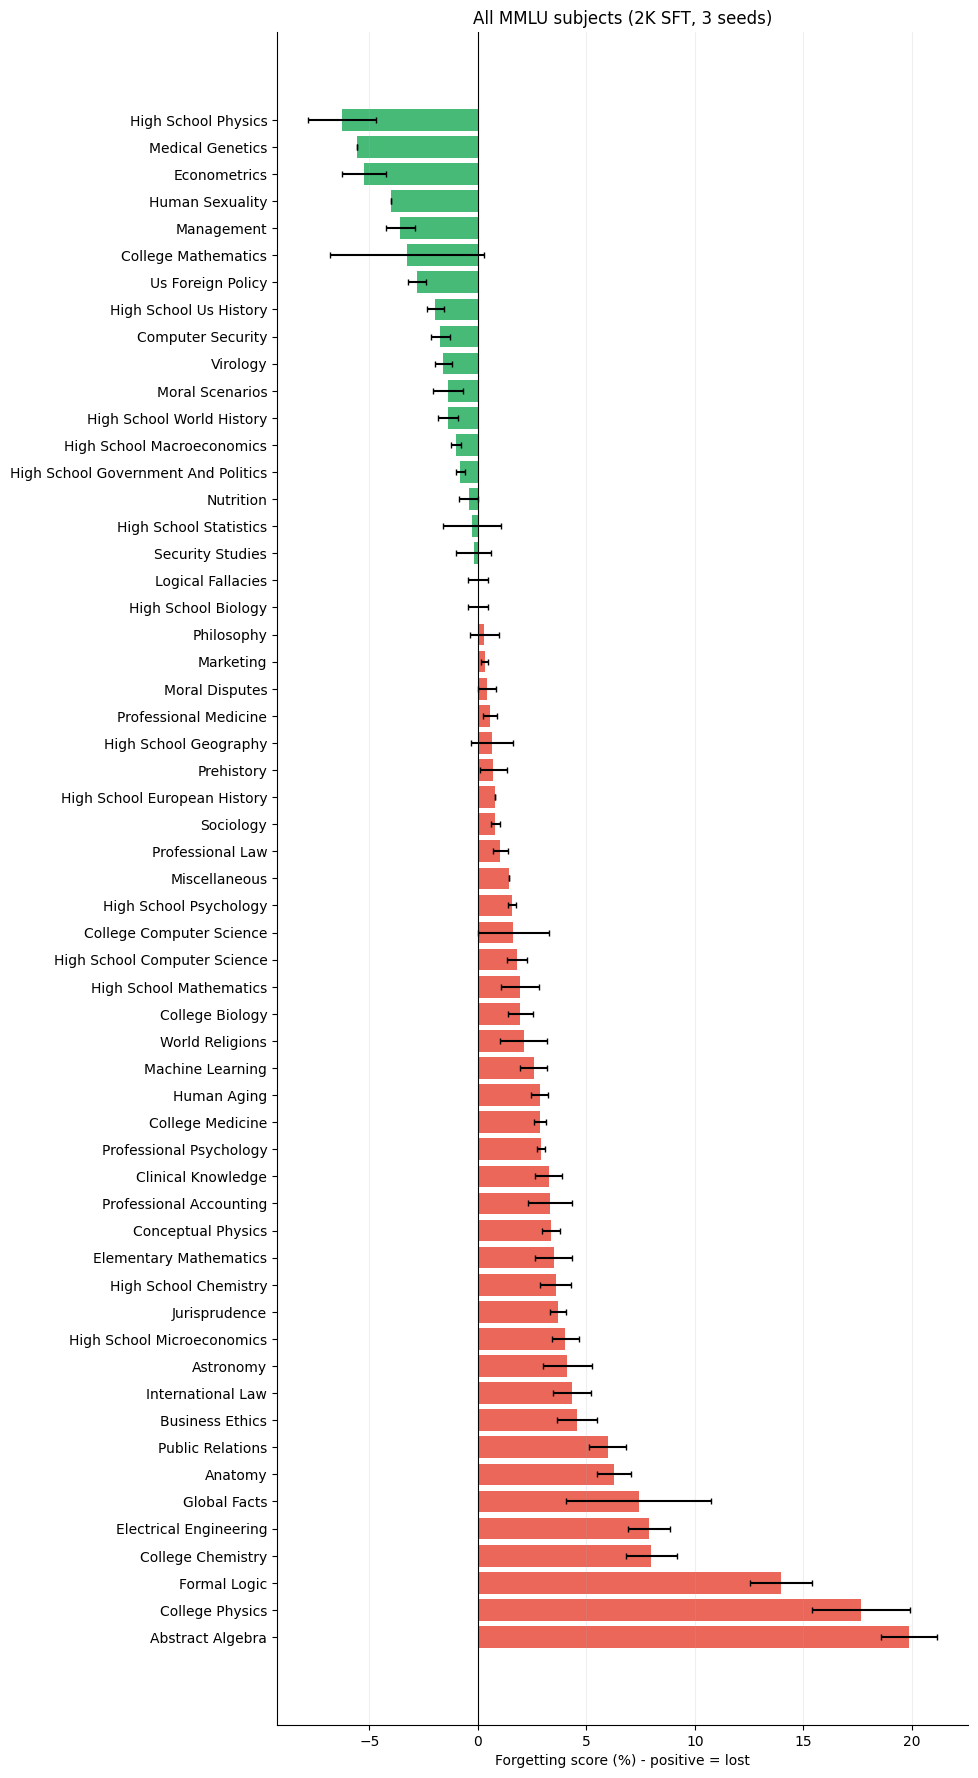

In [9]:
fig, ax = plt.subplots(figsize=(10, 18))

labels = [t.replace('mmlu_','').replace('_',' ').title() for t,_ in sorted_2k]
vals = [v[0] for _,v in sorted_2k]
errs = [v[1] for _,v in sorted_2k]
colors = ['#E74C3C' if v > 0 else '#27AE60' for v in vals]

ax.barh(labels, vals, xerr=errs, color=colors, alpha=0.85, capsize=2)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Forgetting score (%) - positive = lost')
ax.set_title('All MMLU subjects (2K SFT, 3 seeds)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(pad=1.5)
plt.show()


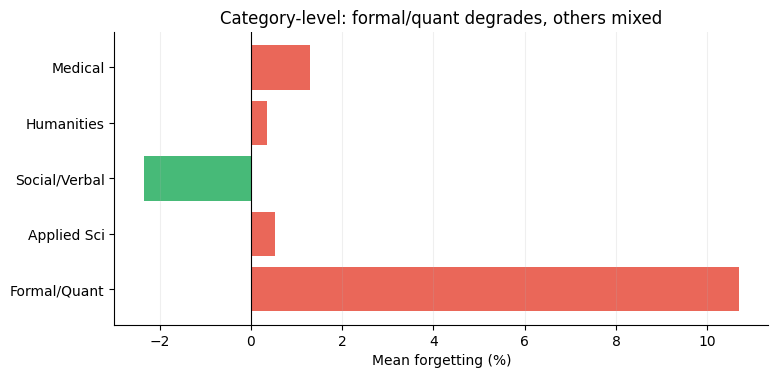

In [10]:
CATS = {
    'Formal/Quant': ['mmlu_abstract_algebra','mmlu_college_physics',
                     'mmlu_formal_logic','mmlu_college_mathematics',
                     'mmlu_electrical_engineering','mmlu_college_chemistry'],
    'Applied Sci':  ['mmlu_high_school_physics','mmlu_conceptual_physics',
                     'mmlu_high_school_chemistry','mmlu_high_school_biology',
                     'mmlu_college_biology'],
    'Social/Verbal':['mmlu_sociology','mmlu_psychology','mmlu_management',
                     'mmlu_marketing','mmlu_human_sexuality','mmlu_econometrics'],
    'Humanities':   ['mmlu_philosophy','mmlu_moral_scenarios','mmlu_prehistory',
                     'mmlu_world_religions','mmlu_logical_fallacies'],
    'Medical':      ['mmlu_medical_genetics','mmlu_clinical_knowledge',
                     'mmlu_anatomy','mmlu_college_medicine','mmlu_nutrition'],
}

cat_means = {}
for cat, tasks in CATS.items():
    vals = [fgt_2k[t][0] for t in tasks if t in fgt_2k]
    if vals:
        cat_means[cat] = statistics.mean(vals)

fig, ax = plt.subplots(figsize=(8, 4))
cats = list(cat_means.keys())
vals = list(cat_means.values())
colors = ['#E74C3C' if v > 0 else '#27AE60' for v in vals]

ax.barh(cats, vals, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean forgetting (%)')
ax.set_title('Category-level: formal/quant degrades, others mixed')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(pad=1.5)
plt.show()


## adaptive self-rehearsal

Probe 5 domains x 30 questions every 25 steps.  
Trigger reweighting (1.5x) after 2 consecutive drops >= threshold.

- THR=10: 0 interventions across all seeds
- THR=5: 1 intervention (seed 1337, step 75, formal_quant)

**why it barely fired:** probes from train splits don't match test distribution.  
5 broad buckets can't catch within-category divergences (HS physics vs college physics are in the same bucket but move opposite).  

**fix:** source probes from held-out benchmark data.


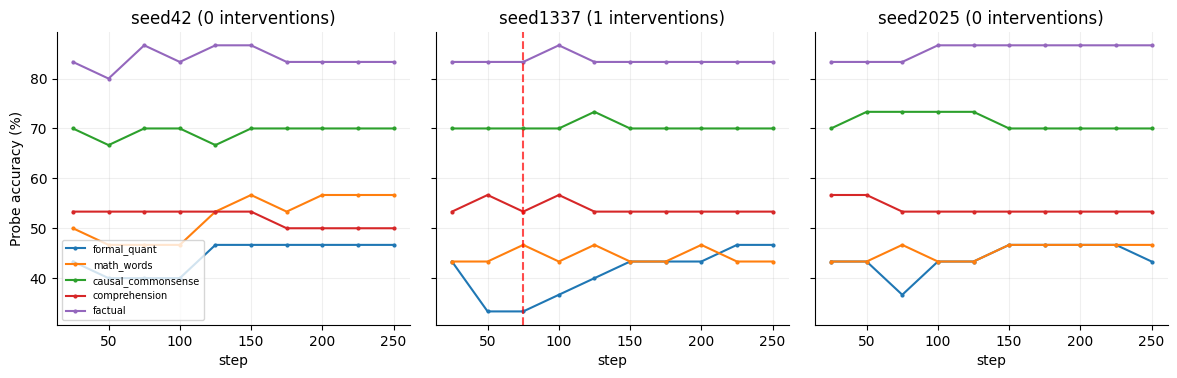

In [11]:
# load probe trajectories if they exist
traj_dir = os.path.join(BASE_DIR, 'adaptive')
traj_files = {}
for seed in ['seed42','seed1337','seed2025']:
    p = os.path.join(traj_dir, f'{seed}-ep4-adaptive', 'probe_trajectory.json')
    if os.path.exists(p):
        traj_files[seed] = json.load(open(p))

if traj_files:
    fig, axes = plt.subplots(1, len(traj_files), figsize=(4*len(traj_files), 4), sharey=True)
    if len(traj_files) == 1: axes = [axes]

    for ax, (seed, traj) in zip(axes, traj_files.items()):
        steps = [e['step'] for e in traj]
        domains = list(traj[0]['accs'].keys())
        for dom in domains:
            accs = [e['accs'][dom]*100 for e in traj]
            ax.plot(steps, accs, marker='.', lw=1.5, ms=4, label=dom)
        # mark interventions
        for e in traj:
            if e.get('interventions'):
                ax.axvline(e['step'], color='red', lw=1.5, ls='--', alpha=0.7)
        n_int = sum(len(e.get('interventions',[])) for e in traj)
        ax.set_title(f'{seed} ({n_int} interventions)')
        ax.set_xlabel('step')
        ax.grid(alpha=0.2)
    axes[0].set_ylabel('Probe accuracy (%)')
    axes[0].legend(fontsize=7, loc='lower left')
    plt.tight_layout(pad=1.5)
    plt.show()
else:
    print("no probe trajectory files found")


-- comparison.png --


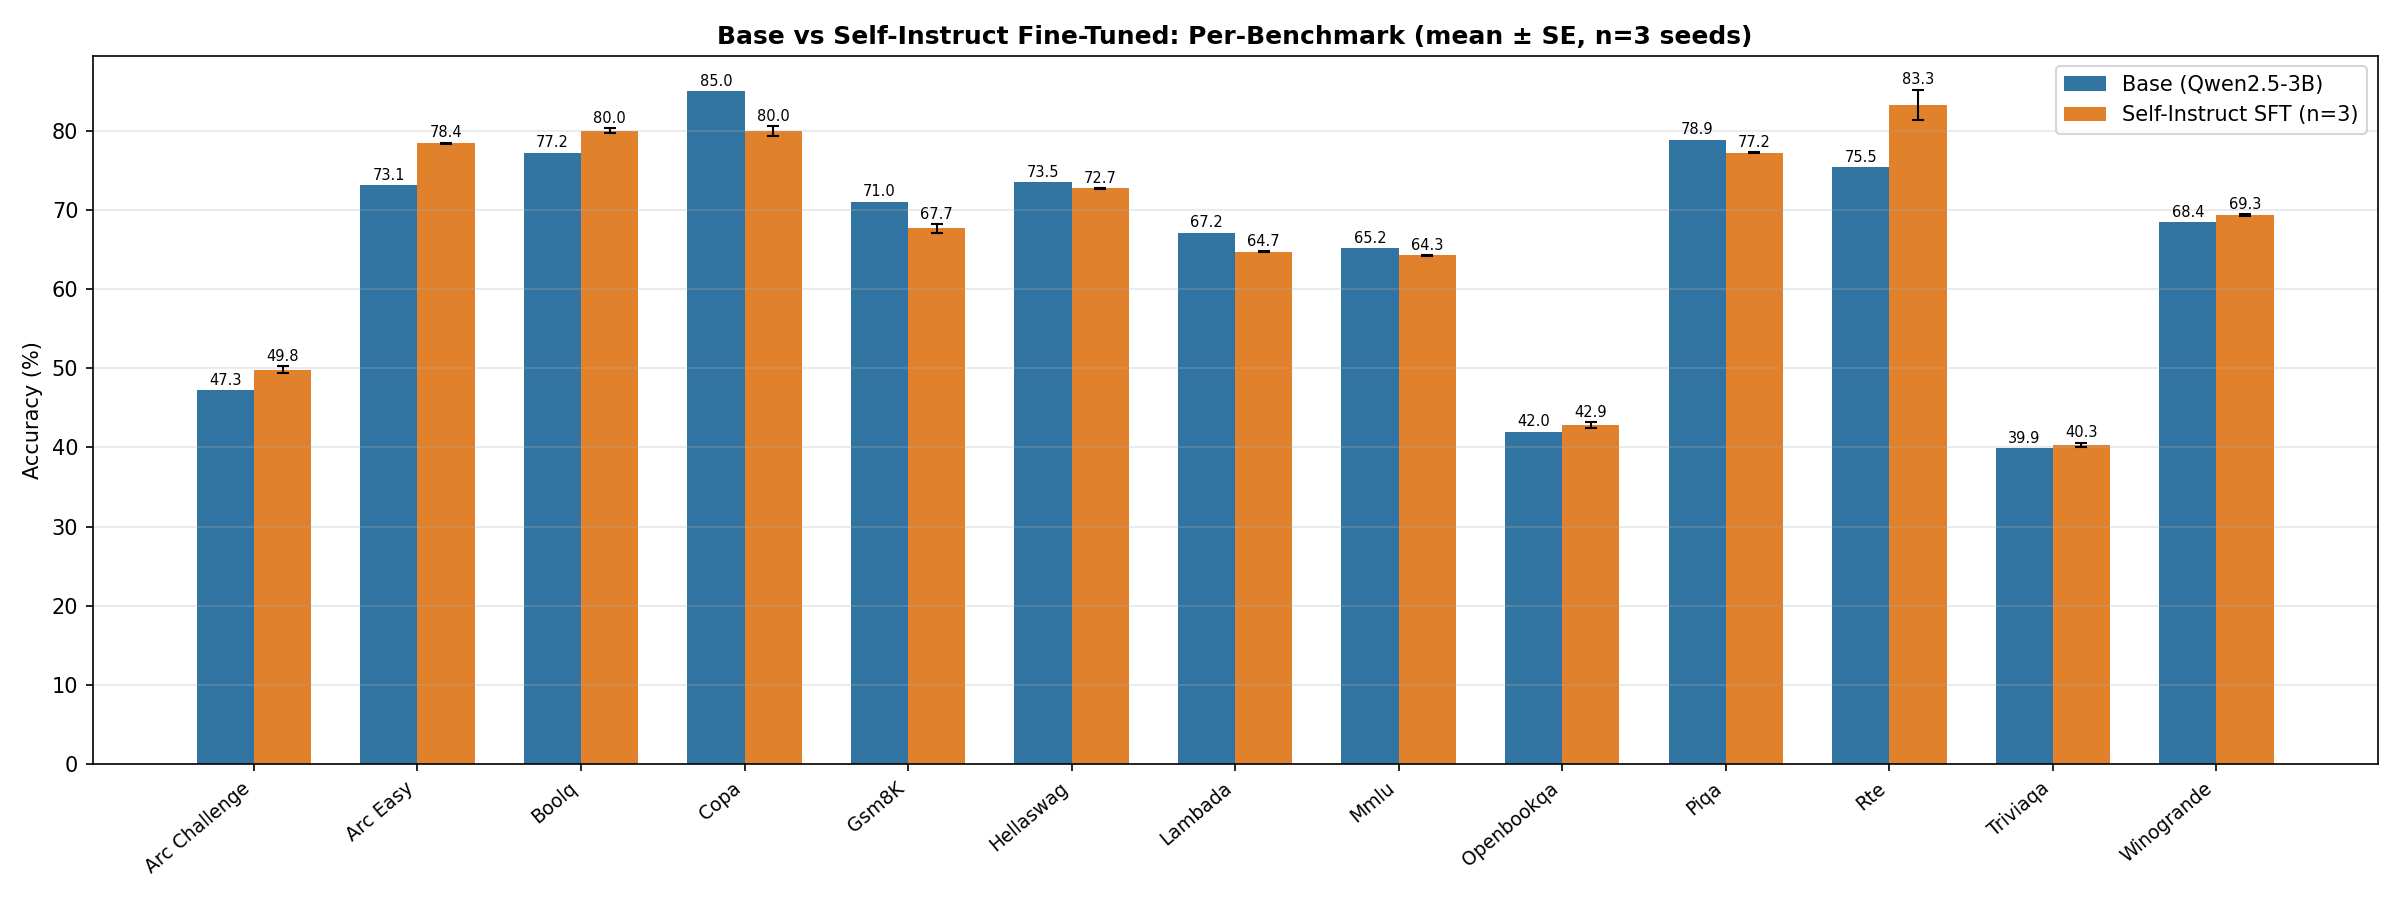

-- forgetting.png --


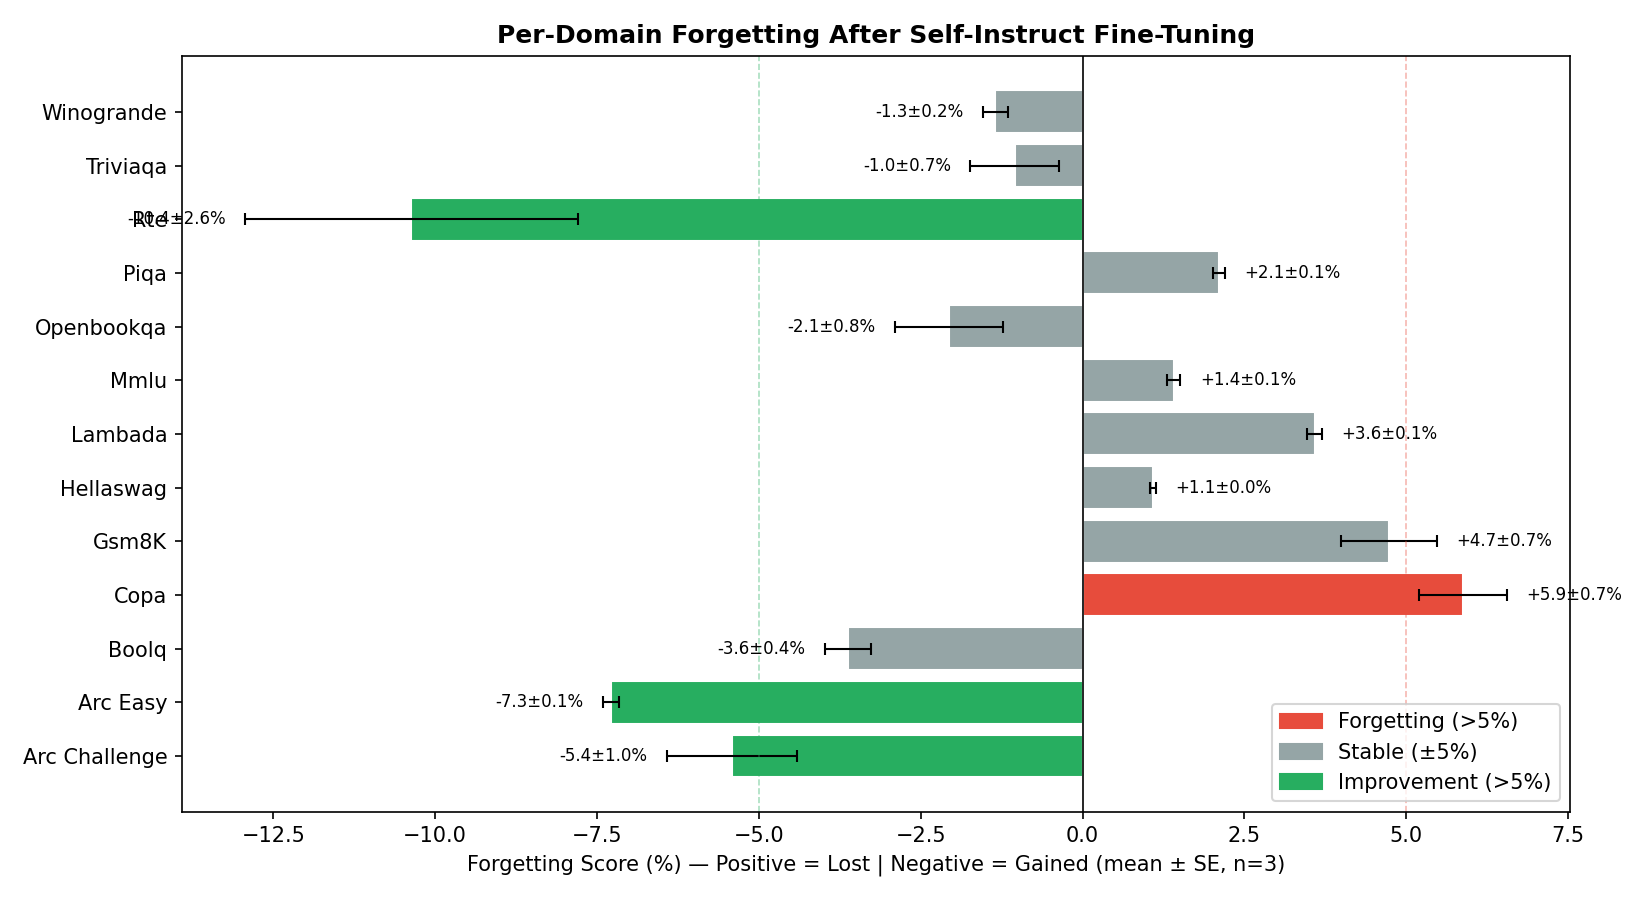

-- seed_consistency.png --


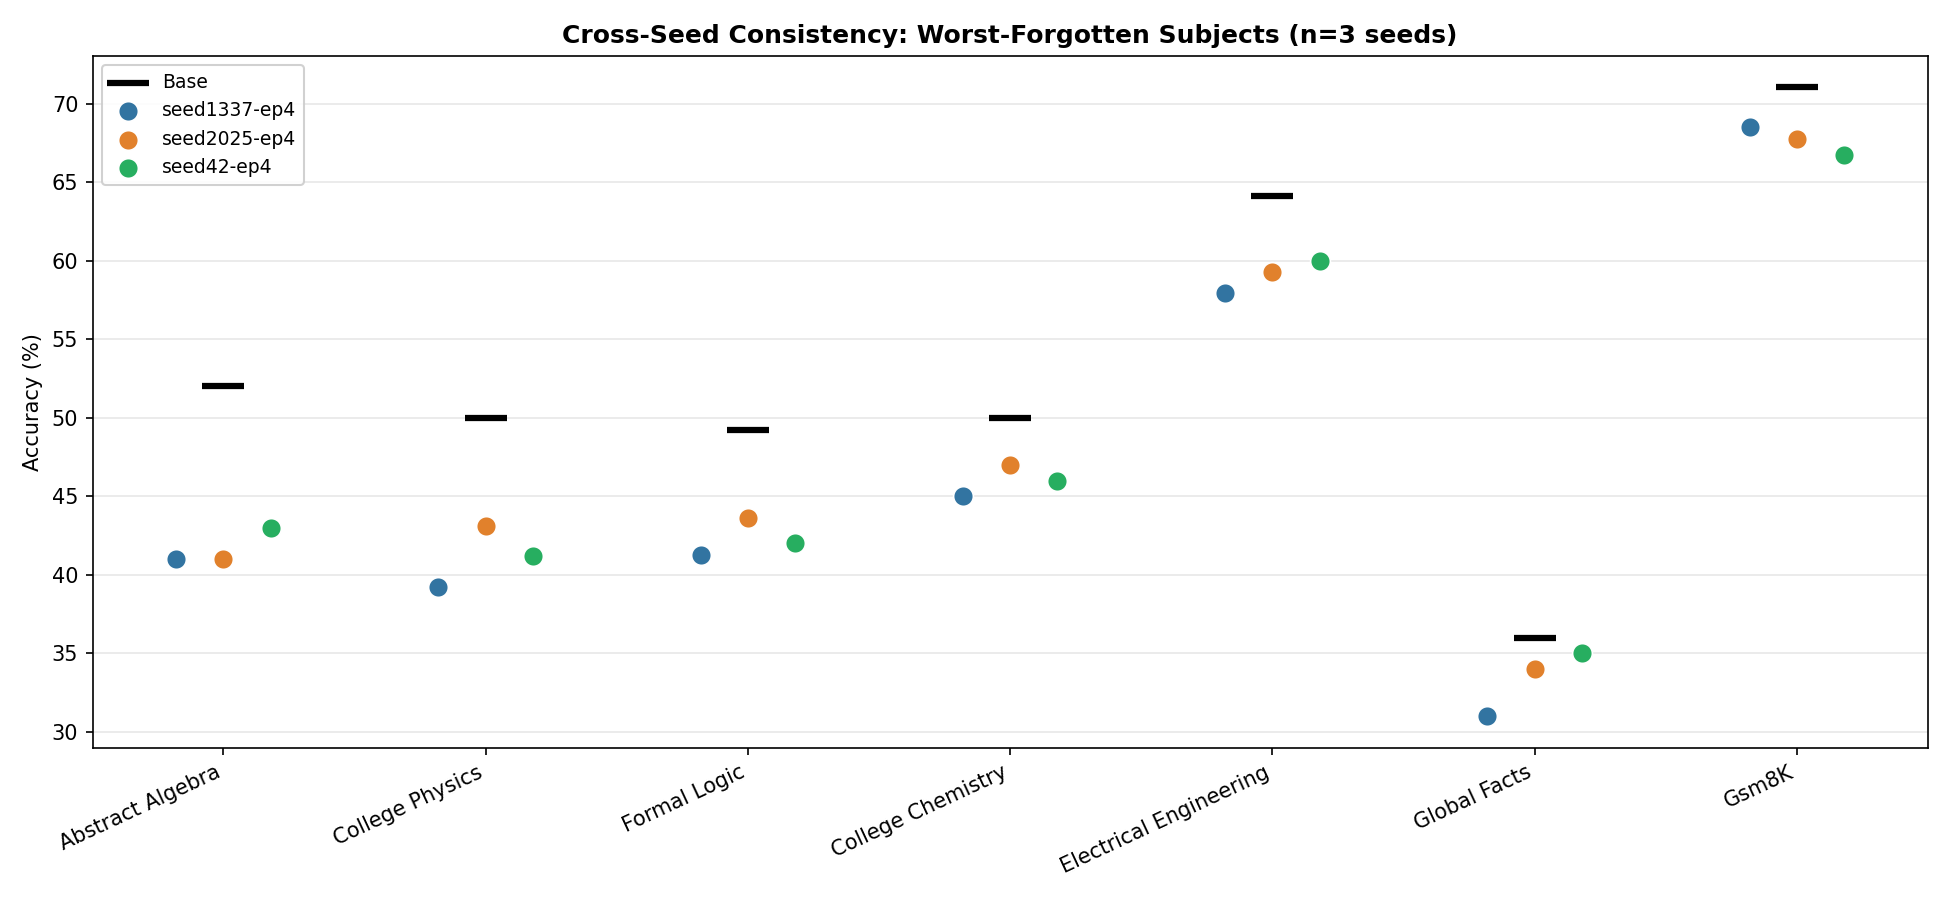

In [12]:
from IPython.display import Image, display

figs_dir = 'final_backup/results/figures'
for fname in ['comparison.png','forgetting.png','seed_consistency.png']:
    p = os.path.join(figs_dir, fname)
    if os.path.exists(p):
        print(f"-- {fname} --")
        display(Image(p, width=800))


## 52K alpaca - forgetting gets much worse

Same model, same protocol. 52K alpaca instructions, 1 epoch, 2 seeds.  
Roughly same gradient steps as 2K x 4 epochs.

- GSM8K: -3.4pp at 2K -> **-15pp at 52K** (~4.5x worse)
- TriviaQA: flat at 2K -> **-17pp at 52K** (caveat: part of this is format drift, exact-match penalizes verbose answers)

Pattern recognition tasks (ARC, BoolQ, WinoGrande) stay stable or improve at both scales.


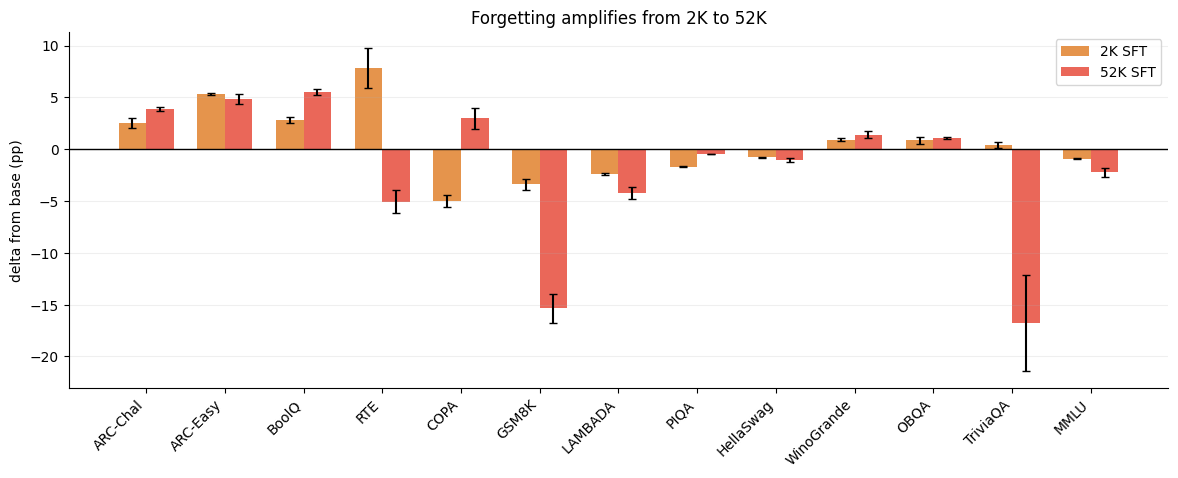

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(TOP_TASKS))
w = 0.35

d2k_v, d52k_v, se2k_v, se52k_v = [], [], [], []
for t in TOP_TASKS:
    _, se2, d2, _ = stats(t, SEEDS_2K)
    _, se5, d5, _ = stats(t, SEEDS_52K)
    d2k_v.append(d2); se2k_v.append(se2)
    d52k_v.append(d5); se52k_v.append(se5)

ax.bar(x - w/2, d2k_v,  w, label='2K SFT', color='#E1812C', alpha=0.85, yerr=se2k_v, capsize=3)
ax.bar(x + w/2, d52k_v, w, label='52K SFT', color='#E74C3C', alpha=0.85, yerr=se52k_v, capsize=3)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[t] for t in TOP_TASKS], rotation=45, ha='right')
ax.set_ylabel('delta from base (pp)')
ax.set_title('Forgetting amplifies from 2K to 52K')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(pad=1.5)
plt.show()


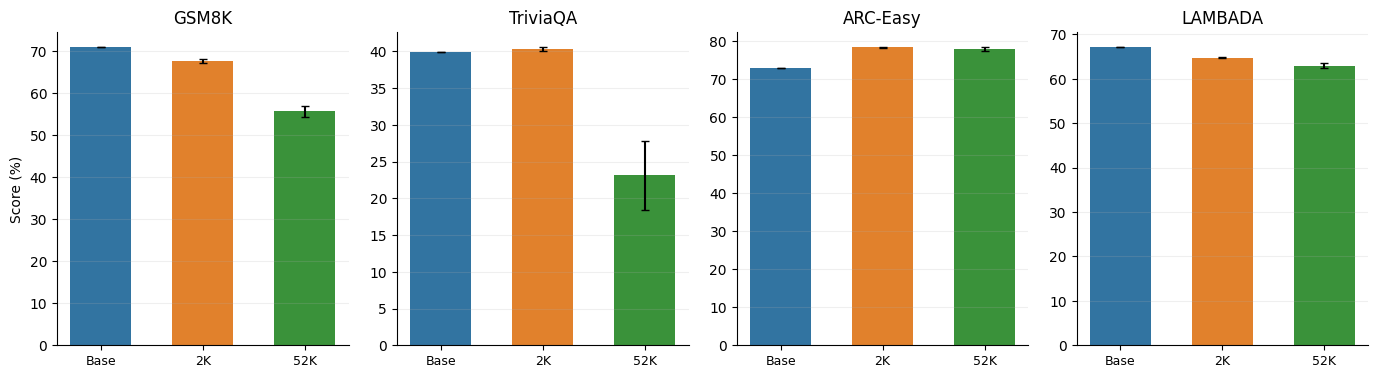

In [14]:
tasks = ['gsm8k', 'triviaqa', 'arc_easy', 'lambada_openai']
labels = ['GSM8K', 'TriviaQA', 'ARC-Easy', 'LAMBADA']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, t, lbl in zip(axes, tasks, labels):
    b = score(conds['base'].get(t, {}))
    m2, se2, _, _ = stats(t, SEEDS_2K)
    m5, se5, _, _ = stats(t, SEEDS_52K)

    ax.bar([0,1,2], [b, m2, m5], color=['#3274A1','#E1812C','#3A923A'],
           yerr=[0, se2, se5], capsize=3, width=0.6)
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(['Base','2K','52K'], fontsize=9)
    ax.set_title(lbl)
    ax.grid(axis='y', alpha=0.2)
    if ax is axes[0]:
        ax.set_ylabel('Score (%)')

plt.tight_layout(pad=1.5)
plt.show()


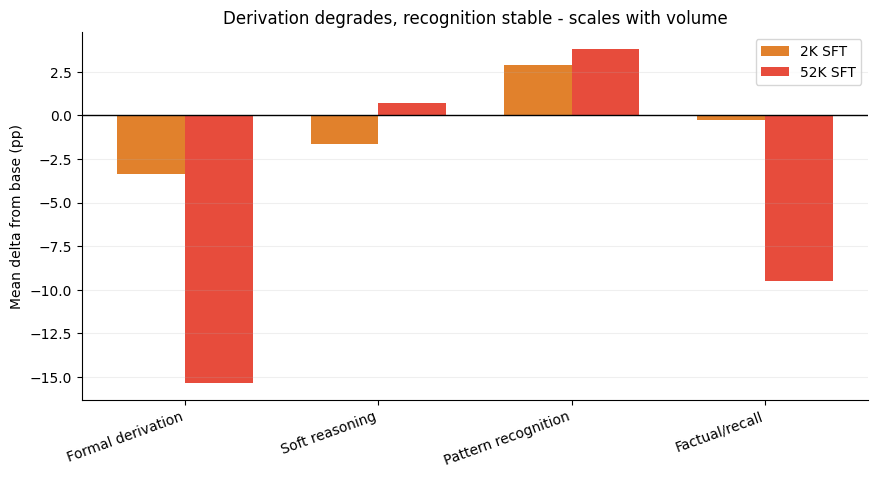

In [15]:
GROUPS = {
    'Formal derivation': ['gsm8k'],
    'Soft reasoning': ['copa', 'hellaswag', 'winogrande', 'piqa'],
    'Pattern recognition': ['arc_easy', 'arc_challenge', 'openbookqa', 'boolq'],
    'Factual/recall': ['triviaqa', 'mmlu'],
}

x = np.arange(len(GROUPS))
w = 0.35

d2_means, d52_means = [], []
for grp, tasks in GROUPS.items():
    d2 = [stats(t, SEEDS_2K)[2] for t in tasks]
    d5 = [stats(t, SEEDS_52K)[2] for t in tasks]
    d2 = [v for v in d2 if v is not None]
    d5 = [v for v in d5 if v is not None]
    d2_means.append(statistics.mean(d2) if d2 else 0)
    d52_means.append(statistics.mean(d5) if d5 else 0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, d2_means,  w, label='2K SFT',  color='#E1812C')
ax.bar(x + w/2, d52_means, w, label='52K SFT', color='#E74C3C')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(list(GROUPS.keys()), rotation=20, ha='right')
ax.set_ylabel('Mean delta from base (pp)')
ax.set_title('Derivation degrades, recognition stable - scales with volume')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(pad=1.5)
plt.show()


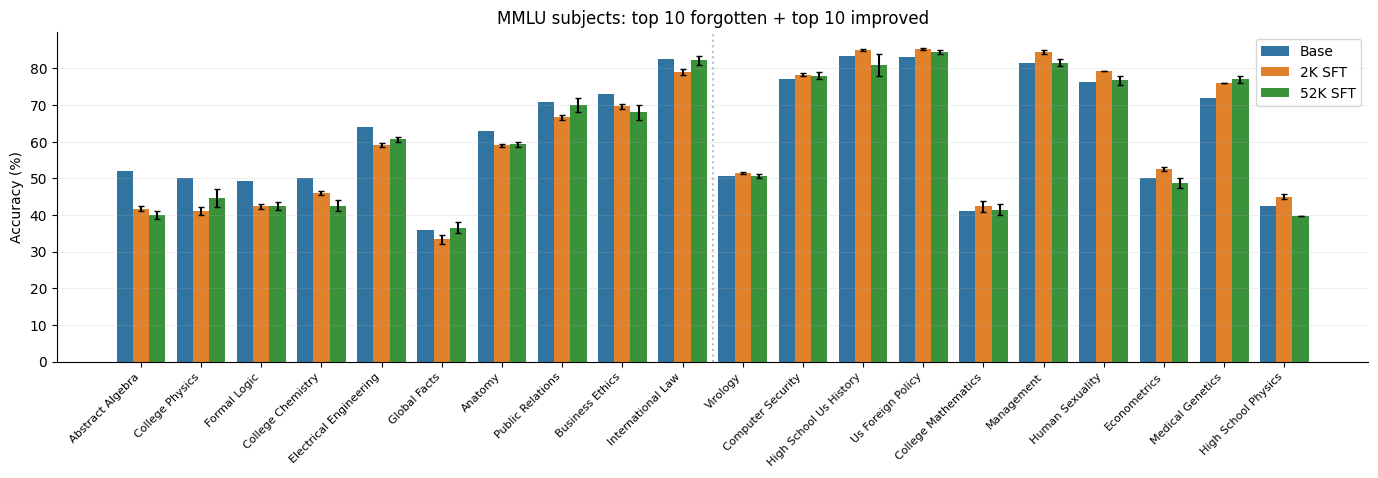

In [16]:
n = 10
show = [t for t,_ in sorted_2k[:n]] + [t for t,_ in sorted_2k[-n:]]

base_s = [score(conds['base'].get(t,{})) for t in show]
m2_s, se2_s, m5_s, se5_s = [], [], [], []
for t in show:
    m, se, _, _ = stats(t, SEEDS_2K);  m2_s.append(m);  se2_s.append(se)
    m, se, _, _ = stats(t, SEEDS_52K); m5_s.append(m);  se5_s.append(se)

x = np.arange(len(show))
w = 0.27

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, base_s, w, label='Base', color='#3274A1')
ax.bar(x,     m2_s,   w, label='2K SFT', color='#E1812C', yerr=se2_s, capsize=2)
ax.bar(x + w, m5_s,   w, label='52K SFT', color='#3A923A', yerr=se5_s, capsize=2)
ax.set_xticks(x)
ax.set_xticklabels([t.replace('mmlu_','').replace('_',' ').title() for t in show],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy (%)')
ax.set_title('MMLU subjects: top 10 forgotten + top 10 improved')
ax.legend()
ax.grid(axis='y', alpha=0.2)
ax.axvline(n - 0.5, color='gray', ls=':', alpha=0.5)
plt.tight_layout(pad=1.5)
plt.show()


## conclusions

1. **forgetting is real but selective.** MMLU aggregate (-0.92pp) hides a 26pp divergence across subjects.

2. **cognitive axis, not subject taxonomy.** Formal derivation tasks (abstract algebra, college physics, formal logic, GSM8K) degrade. Pattern recognition and recall tasks improve. Same category can go both directions.

3. **scales with instruction volume.** GSM8K: -3.4pp at 2K -> -15pp at 52K (~4.5x worse). Motivates per-domain monitoring.

4. **ASR barely fires** because probe-test distribution mismatch. This is a design flaw we diagnosed, not a theoretical failure. Fix: sample probes from held-out benchmark data.

---

$$F_d = \frac{B_d - C_d}{B_d}$$

$B_d$ = base accuracy, $C_d$ = post-SFT accuracy. Positive = performance lost.

---

*Honest scope:* single model family (Qwen2.5-3B), TriviaQA 52K result has format-drift confound, ASR only tested at 2K scale. Probe mismatch is a correctable design flaw — not a refutation of adaptive rehearsal.
